In [1]:
# pip install pdf2image opencv-python matplotlib numpy
# pdf2image requiere poppler instalado en el sistema (apt install poppler-utils)

import fitz  
# Reemplazamos 'pdf2image' por 'fitz' (PyMuPDF).
# El perfilado de rendimiento demostró que pdf2image lanza un subproceso 
# externo del sistema operativo (pdftoppm de Poppler) en cada llamada. Esto genera un cuello
# de botella masivo de I/O. PyMuPDF realiza el renderizado nativo en C dentro del mismo proceso 
# de Python, reduciendo los tiempos de carga en ~3.5x por acta.
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Calibration parameters

In [2]:
# PARÁMETROS DE CALIBRACIÓN

DPI_CALIBRACION = 200
BASE_BLOCK_SIZE = 25   # Valor que funcionaba a 200 DPI
BASE_KERNEL_LEN = 120  # Valor que funcionaba a 200 DPI

DPI_LECTURA = 100       # Resolución real
FACTOR_REDUCCION = 0.75  # 1.0 = no reducir, 0.5 = reducir a la mitad la matriz

### Original image loading

Tamaño original leído nativamente: (4987, 3539, 3)


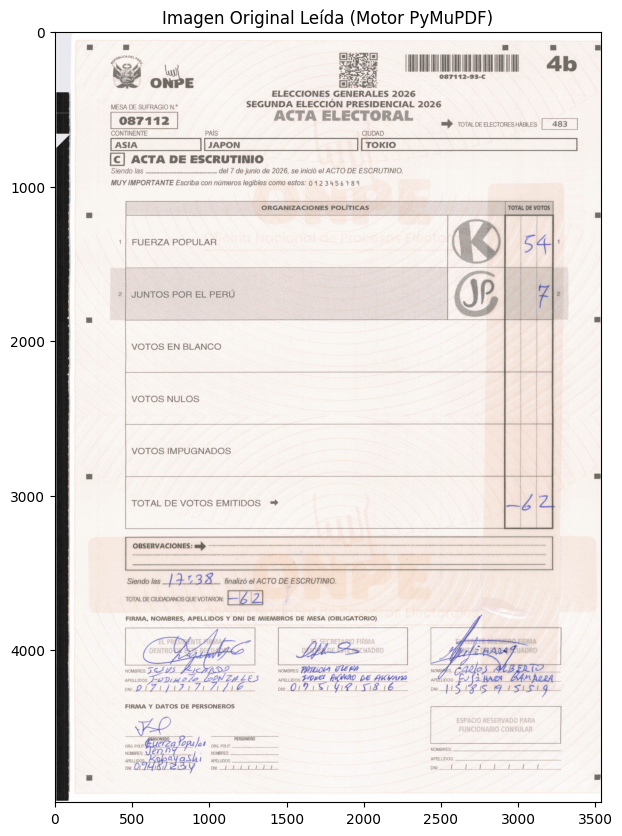

In [3]:
doc = fitz.open("acta_test3.pdf")
page = doc[0]

# PyMuPDF trabaja con puntos tipográficos (72 puntos por pulgada) en lugar de DPI directos.
# Escalamos la matriz de transformación (Matrix) para obtener los 100 DPI que definimos.
zoom = DPI_LECTURA / 72  
mat = fitz.Matrix(zoom, zoom)
pix = page.get_pixmap(matrix=mat)

# Reconstruimos el array NumPy directamente desde el buffer de memoria nativo en C
img_np = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
img = cv2.cvtColor(img_np, cv2.COLOR_RGBA2BGR if pix.n == 4 else cv2.COLOR_RGB2BGR)
doc.close()

print(f"Tamaño original leído nativamente: {img.shape}")
plt.figure(figsize=(8,10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Imagen Original Leída (Motor PyMuPDF)")
plt.show()

### Binarization

Tamaño reducido a procesar morfológicamente: (3740, 2654)


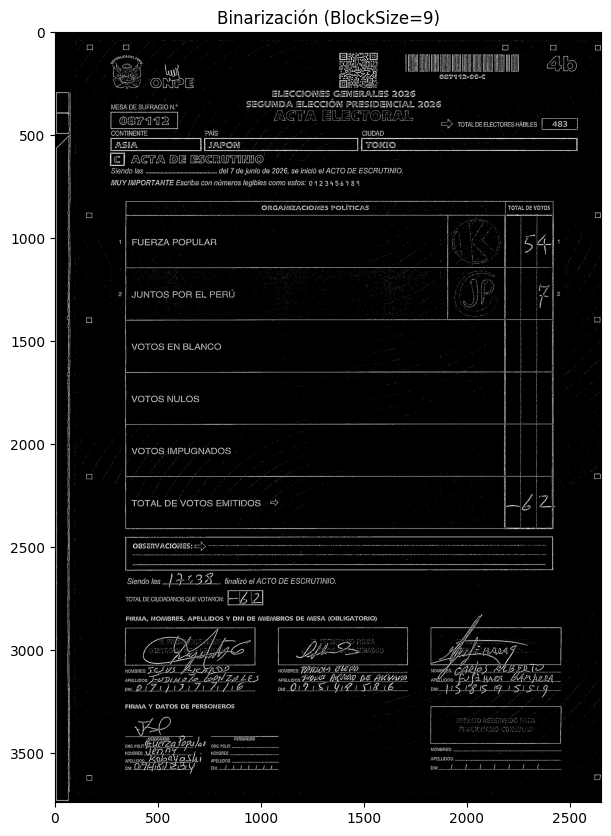

CPU times: user 1.04 s, sys: 185 ms, total: 1.22 s
Wall time: 1.05 s


In [4]:
%%time

# Densidad de píxeles real de la matriz FINAL que procesará OpenCV
DPI_EFECTIVO = DPI_LECTURA * FACTOR_REDUCCION

# Proporción es esto comparado con nuestra calibración ideal
RATIO_ESCALA = DPI_EFECTIVO / DPI_CALIBRACION

# Ajustamos los parámetros
block_size_escalado = int(BASE_BLOCK_SIZE * RATIO_ESCALA)
# Forzamos impar y mínimo 3
if block_size_escalado % 2 == 0:
    block_size_escalado += 1
block_size_escalado = max(3, block_size_escalado)

# No puede ser menor a 1
kernel_length = max(1, int(BASE_KERNEL_LEN * RATIO_ESCALA)) 


gray_orig = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Reducimos la imagen para procesar la geometría mucho más rápido
# INTER_AREA es fundamental para no perder líneas delgadas al reducir
gray = cv2.resize(gray_orig, None, fx=FACTOR_REDUCCION, 
                  fy=FACTOR_REDUCCION, interpolation=cv2.INTER_AREA)
print(f"Tamaño reducido a procesar morfológicamente: {gray.shape}")

# Binarización adaptativa: convierte cada píxel a blanco o negro
# según el contraste local (mejor que un umbral fijo para escaneos)
# https://stackabuse.com/opencv-adaptive-thresholding-in-python-with-cv2adaptivethreshold/
binary = cv2.adaptiveThreshold(
    src=gray, maxValue=255,
    # Calcula el umbral local usando una media gaussiana.
    adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    # invertido: líneas = blanco (255), fondo = negro (0)
    thresholdType=cv2.THRESH_BINARY_INV,
    # Tunear en impares
    blockSize=block_size_escalado,
    # Tunear de dos en dos
    C=12 # La C nunca se escala
)

plt.figure(figsize=(8,10))
plt.imshow(binary, cmap='gray')
plt.title(f"Binarización (BlockSize={block_size_escalado})")
plt.show()

### Mathematical Morphology

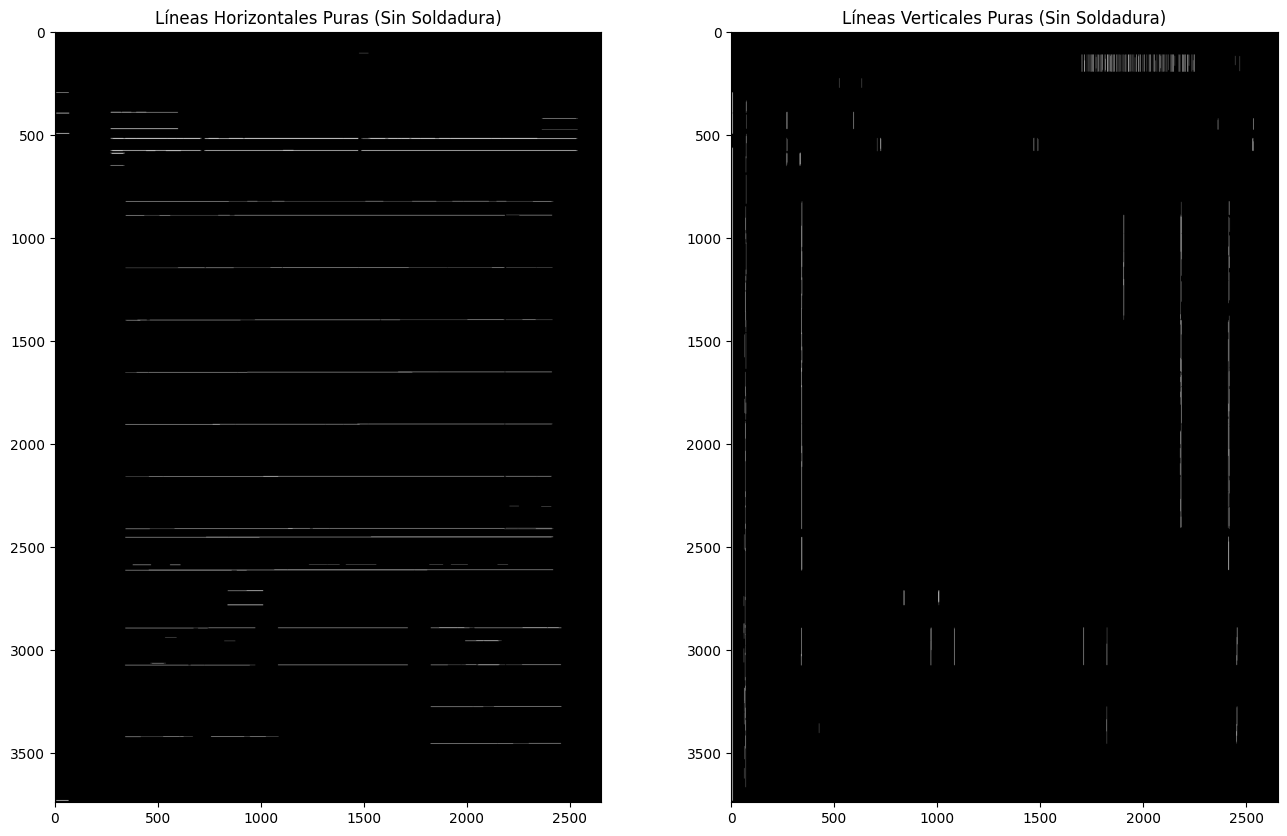

CPU times: user 1.71 s, sys: 205 ms, total: 1.92 s
Wall time: 1.92 s


In [5]:
%%time
# Morphological operations
# https://www.geeksforgeeks.org/python/python-opencv-morphological-operations/
# https://opencv24-python-tutorials.readthedocs.io/en/latest/py_tutorials/py_imgproc/py_morphological_ops/py_morphological_ops.html
# Kernel horizontal: muy ancho, 1 píxel de alto
# Solo sobrevive lo que es horizontal y largo (líneas de tabla)

# Dimensiones reducidas para calcular el tamaño de nuestras "soldaduras"
h_reduced, w_reduced = binary.shape[:2]
img_h, img_w = img.shape[:2]

# Extraemos trazos puros horizontales largos usando MORPH_OPEN
horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_length, 1))
horizontal_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, horizontal_kernel)

# Extraemos trazos puros verticales largos usando MORPH_OPEN
vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, kernel_length))
vertical_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, vertical_kernel)

'''
CAMBIO DE ESTRATEGIA: Los trazos de los miembros de mesa raramente rompen el 
núcleo impreso de la tabla de votos de manera severa. Al aplicar la soldadura 
de forma especulativa, el algoritmo tendía a 'atrapar' ruido visual adyacente 
(manchas, fragmentos de letras manuscritas) y los soldaba a la cuadrícula, 
generando líneas fantasmas y una celda espuria (falsa). 
Lección: Quitar el MORPH_CLOSE simplifica el código, elimina falsos positivos y 
hace que el esqueleto sea puramente representativo de la geometría real impresa.
'''

fig, ax = plt.subplots(1, 2, figsize=(16, 10))
ax[0].imshow(horizontal_lines, cmap='gray')
ax[0].set_title("Líneas Horizontales Puras (Sin Soldadura)")
ax[1].imshow(vertical_lines, cmap='gray')
ax[1].set_title("Líneas Verticales Puras (Sin Soldadura)")
plt.show()

### Contour retrieval

In [6]:
'''
CAMBIO DE ESTRATEGIA: Antes se sumaban las máscaras cv2.add) y se buscaba contornos 
cerrados de forma directa (cv2.findContours con RETR_TREE).

El enfoque de 'buscar cajas cerradas' es frágil: si un escaneo de baja tinta borra 
un solo milímetro del borde exterior, la caja se rompe, se fusiona con la columna vecina 
y rompe todo el índice de celdas.

Ahora, desacoplamos el análisis en proyecciones 1D (analizar X e Y de forma independiente):
1. Extraemos las coordenadas horizontales de las líneas que pasen el filtro de longitud.
2. Extraemos las coordenadas verticales y registramos su extensión real en Y (su techo y su piso).
Todo se convierte inmediatamente a la escala de la imagen ORIGINAL dividiendo entre FACTOR_REDUCCION.
'''

# Procesamiento de Líneas Horizontales
# hierarchy no es usado
contornos_h, _ = cv2.findContours(horizontal_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Alturas donde existe una linea horizontal. Da los cortes precisos 
# para separar las filas (Partido A, Partido B).
y_coords = []
# Lugar donde terminan por la derecha las líneas más largas.
# Asegura que la caja se cierre correctamente por la derecha
bordes_derechos = []

LINEA_HORIZONTAL_MIN_PCT = 0.15  # Debe cubrir al menos 15% del ancho de página
LINEA_VERTICAL_MIN_PCT = 0.05    # Debe cubrir al menos 5% del alto de página
LINEA_LARGUISIMA_PCT = 0.40      # Umbral para considerarla "borde derecho confiable"

for c in contornos_h:
    x, y, w, h = cv2.boundingRect(c)
    # Evita que el algoritmo confunda un guion bajo (> 15% width)
    if w > w_reduced * LINEA_HORIZONTAL_MIN_PCT:
        # Centro del grosor de la linea
        y_coords.append(int((y + h / 2) / FACTOR_REDUCCION))
    # No veo la pared, pero sé que la tabla termina matemáticamente aquí
    if w > w_reduced * LINEA_LARGUISIMA_PCT:
        bordes_derechos.append(int((x + w) / FACTOR_REDUCCION))

# Para comparación de líneas sucesivas
y_coords.sort()
TOLERANCIA_AGRUPAR_Y_PCT = 0.015 # Fusión de líneas horizontales duplicadas
# Deduplicación de coordenadas Y cercanas (varias detecciones de la misma línea física)
tolerancia_y = img_h * TOLERANCIA_AGRUPAR_Y_PCT
y_unicas = []
for y in y_coords:
    if not y_unicas or (y - y_unicas[-1]) > tolerancia_y:
        y_unicas.append(y)



# Procesamiento de Líneas Verticales
contornos_v, _ = cv2.findContours(vertical_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
lineas_v = []
for c in contornos_v:
    x, y, w, h = cv2.boundingRect(c)
    # Evita que el algoritmo agregue ruido (> 5% height)
    if h > h_reduced * LINEA_VERTICAL_MIN_PCT:
        # Coordenadas de las líneas
        x_centro = int((x + w / 2) / FACTOR_REDUCCION)
        y_techo = int(y / FACTOR_REDUCCION)
        y_piso = int((y + h) / FACTOR_REDUCCION)
        lineas_v.append((x_centro, y_techo, y_piso))

# Para comparación de líneas sucesivas
lineas_v.sort(key=lambda item: item[0])

x_unicas = []
x_spans = {}  # Guarda el rango {x: [y_min, y_max]} real de cada pared vertical
TOLERANCIA_AGRUPAR_X_PCT = 0.02  # Fusión de paredes verticales duplicadas
tolerancia_x = img_w * TOLERANCIA_AGRUPAR_X_PCT

'''
Las líneas verticales de las tablas casi siempre están rotas en la imagen 
binarizada. ¿Por qué? Porque son atravesadas perpendicularmente por líneas 
horizontales, o porque un miembro de mesa estampó un sello encima, 
partiéndola. OpenCV detectará cada segmento como un contorno independiente.

La solución analítica: El código revisa si el nuevo segmento detectado 
comparte la misma coordenada X (dentro de la tolerancia) que el segmento 
anterior. Si es así, deduce que son la misma pared física que fue 
fragmentada.

La expansión: Se usa min() para empujar el techo hacia arriba y max() 
para empujar el piso hacia abajo, fusionando matemáticamente los segmentos 
hasta reconstruir la altura total ininterrumpida de la columna, sin generar 
el "ruido visual" que causaba el MORPH_CLOSE.

EJEMPLO: Consideremos dos fragmentos: A desde Y = 400 hasta Y = 700, y
B desde Y = 800 hasta Y = 1200. Techo del Fragmento A: 400. Techo del 
Fragmento B: 800 -> Nuevo Techo = min(400, 800) = 400. Es decir, 
obligamos a que la pared final empiece desde lo más alto que llegó 
cualquier fragmento. Similarmente, con  los pisos.

'''    
for x, y1, y2 in lineas_v:
    # Distancia entre la línea actual y la última > 2% width
    if not x_unicas or (x - x_unicas[-1]) > tolerancia_x:
        x_unicas.append(x)
        x_spans[x] = [y1, y2] 
    else:
        x_clave = x_unicas[-1]
        x_spans[x_clave][0] = min(x_spans[x_clave][0], y1)
        x_spans[x_clave][1] = max(x_spans[x_clave][1], y2)


SALVAVIDAS_GAP_MIN_PCT = 0.04    # Distancia mínima para reconstruir pared faltante
CELDA_ALTO_MIN_PCT = 0.015       # Descarta filas colapsadas o ruido


# El Salvavidas del Borde Derecho
# Si el escaneo mutiló la última pared derecha de la tabla, las 
# líneas horizontales sí saben dónde debería terminar térmicamente 
# (borde_derecho_tipico). Si detectamos un vacío enorme al final de 
# x_unicas, inyectamos artificialmente la pared faltante copiando el 
# span vertical de su vecina.

# Calcular matemáticamente dónde debería terminar el lado derecho de la tabla
bordes_derechos.sort() # Para tomar el valor del medio
# Calcula la mediana (ignora los valores extremos (outliers) y toma el del centro)
borde_derecho_tipico = bordes_derechos[len(bordes_derechos) // 2] \
                        if bordes_derechos else 0

if x_unicas and borde_derecho_tipico > 0:
    if (borde_derecho_tipico - x_unicas[-1]) > img_w * SALVAVIDAS_GAP_MIN_PCT:
        pared_vecina = x_unicas[-1]
        x_unicas.append(borde_derecho_tipico)
        x_spans[borde_derecho_tipico] = x_spans[pared_vecina].copy()
        print(f"-> [SALVAVIDAS ACTIVADO]: Se reconstruyó la pared derecha \
        perdida en X = {borde_derecho_tipico}")

print(f"Coordenadas Y maestras (horizontales): {y_unicas}")
print(f"Coordenadas X maestras (verticales): {x_unicas}")

Coordenadas Y maestras (horizontales): [689, 766, 1096, 1187, 1526, 1864, 2202, 2540, 2878, 3216, 3484, 3858, 4098, 4368, 4607]
Coordenadas X maestras (verticales): [10, 92, 457, 2540, 2907, 3217]


### Visualization

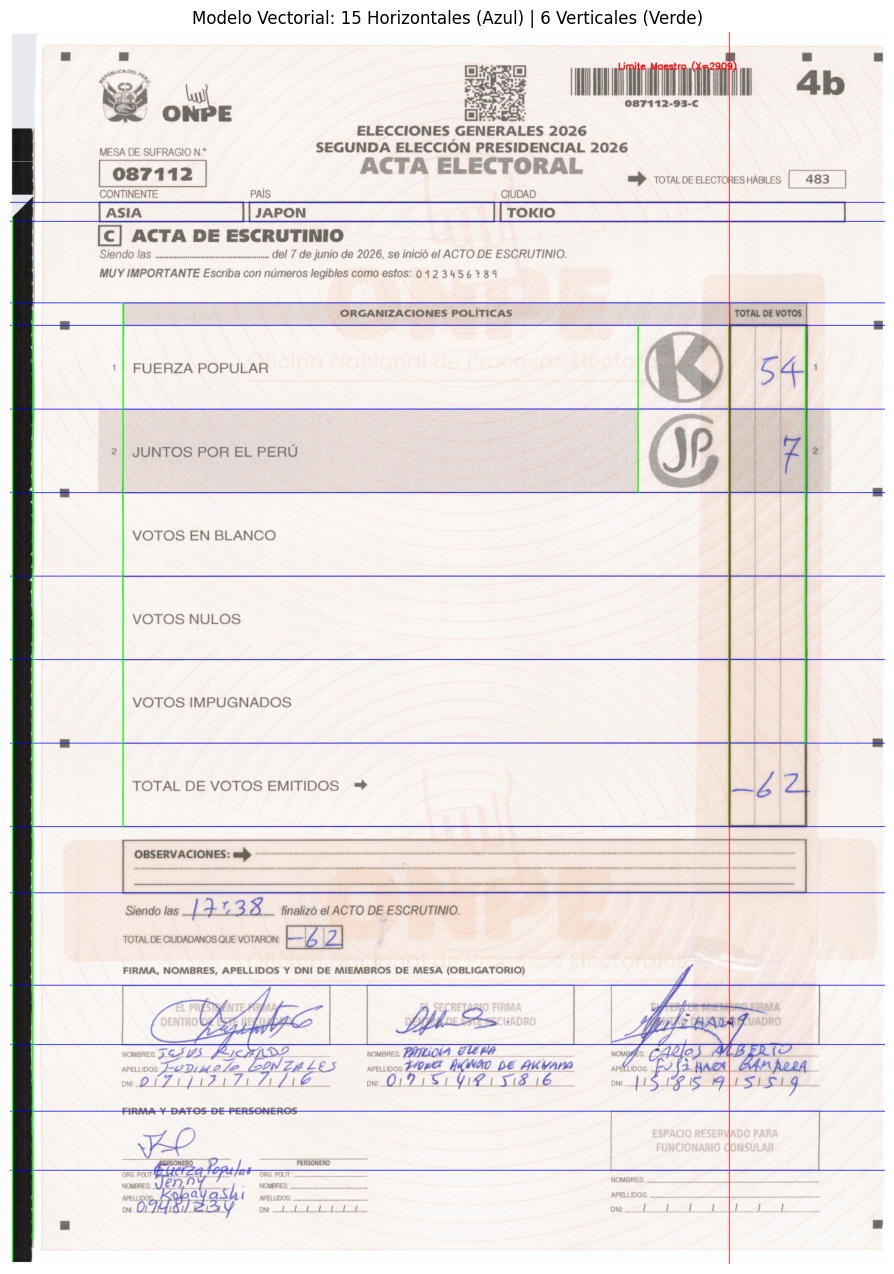

In [7]:
'''
VISUALIZACIÓN DEL ESQUELETO MATEMÁTICO (Coordenadas Maestras)

Dibujamos las líneas proyectadas sobre una copia de la imagen original
para verificar que las coordenadas maestras (1D) mapean perfectamente 
la estructura de la tabla física.

'''
debug_esqueleto = img.copy()

# 1. Trazar las "Cuchillas" Horizontales (y_unicas) en AZUL
# Trazamos una línea de extremo a extremo de la página en cada altura registrada.
for y in y_unicas:
    cv2.line(debug_esqueleto, (0, y), (img_w, y), (255, 0, 0), 2)

# 2. Trazar los "Muros" Verticales (x_unicas y x_spans) en VERDE
# Aquí notarás la magia: las líneas no cruzan toda la página, 
# solo se dibujan desde su 'techo' real hasta su 'piso' real.
for x in x_unicas:
    y_min, y_max = x_spans[x]
    cv2.line(debug_esqueleto, (x, y_min), (x, y_max), (0, 255, 0), 4)

# 3. Trazar el Límite del Salvavidas en ROJO
# Mostramos dónde calculó el algoritmo que debe terminar la tabla por la derecha.
if borde_derecho_tipico > 0:
    cv2.line(debug_esqueleto, (borde_derecho_tipico, 0), \
             (borde_derecho_tipico, img_h), (0, 0, 255), 2)
    cv2.putText(debug_esqueleto, f"Limite Maestro (X={borde_derecho_tipico})", 
                (borde_derecho_tipico - 450, 150), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)

plt.figure(figsize=(12, 16))
plt.imshow(cv2.cvtColor(debug_esqueleto, cv2.COLOR_BGR2RGB))
plt.title(f"Modelo Vectorial: {len(y_unicas)} Horizontales (Azul) | {len(x_unicas)} Verticales (Verde)")
plt.axis('off')
plt.show()